In [140]:
import numpy as np 
import pandas as pd 
import math
import matplotlib.pyplot as plt


path = "/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv"

df = pd.read_csv(path)


In [141]:
media_sales = df['Weekly_Sales'].mean()
desvio_sales = df['Weekly_Sales'].std()
df['Data_Tratada'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Date'] = df['Data_Tratada'].astype('int64') // 10**9
del df["Data_Tratada"]
del df["Store"]
feature_cols = ['CPI', 'Temperature', 'Date', 'Weekly_Sales']
df[feature_cols] = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
print(df.head())

       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price       CPI  \
0 -1.719847      1.057338             0    -0.995058       2.572  1.004097   
1 -1.695624      1.054266             1    -1.201077       2.548  1.007802   
2 -1.671401      1.001128             0    -1.124091       2.514  1.008996   
3 -1.647177      0.642778             0    -0.760848       2.561  1.009771   
4 -1.622954      0.899844             0    -0.767896       2.625  1.010546   

   Unemployment  
0         8.106  
1         8.106  
2         8.106  
3         8.106  
4         8.106  


In [142]:
Y_train = df['Weekly_Sales'].values
print(Y_train)
del df["Weekly_Sales"]
X_train = df
print(X_train.head())

[ 1.05733755  1.05426604  1.00112811 ... -0.55371899 -0.58266973
 -0.50797378]
       Date  Holiday_Flag  Temperature  Fuel_Price       CPI  Unemployment
0 -1.719847             0    -0.995058       2.572  1.004097         8.106
1 -1.695624             1    -1.201077       2.548  1.007802         8.106
2 -1.671401             0    -1.124091       2.514  1.008996         8.106
3 -1.647177             0    -0.760848       2.561  1.009771         8.106
4 -1.622954             0    -0.767896       2.625  1.010546         8.106


In [143]:
def compute_cost(w, b, x, y):
    m = x.shape[0]
    fw_b = np.dot(x, w) + b
    
    cost = np.sum((fw_b - y) ** 2) / (2 * m)
    return cost


In [144]:
def compute_gradient(w, b, x, y):
    m = x.shape[0]
    
   
    fw_b = np.dot(x, w) + b
    
 
    error = fw_b - y
    
    
    dw = (1 / m) * np.dot(x.T, error)
    
    
    db = (1 / m) * np.sum(error)
    
    return dw, db

In [145]:
def linear_regression(w, b, x, y,compute_cost, compute_gradient, alpha, iterations):
    J_history = []
    w_history = []
    for i in range(iterations):
        dw,db = compute_gradient(w,b,x,y)
        w = w - alpha*dw
        b = b - alpha*db
        if i<100000:      
            cost =  compute_cost(w, b, x, y)
            J_history.append(cost)

        
        if i% math.ceil(iterations/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
    return w, b, J_history, w_history
    

In [146]:

initial_w = np.zeros(X_train.shape[1])
initial_b = 0.0
X_train = np.asarray(X_train, dtype=np.float64)
Y_train = np.asarray(Y_train, dtype=np.float64)


iterations = 1500
alpha = 0.001

w,b,_,_ = linear_regression(initial_w, initial_b, X_train ,Y_train, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     0.50   
Iteration  150: Cost     0.50   
Iteration  300: Cost     0.50   
Iteration  450: Cost     0.49   
Iteration  600: Cost     0.49   
Iteration  750: Cost     0.49   
Iteration  900: Cost     0.49   
Iteration 1050: Cost     0.49   
Iteration 1200: Cost     0.49   
Iteration 1350: Cost     0.49   
w,b found by gradient descent: [-0.01008306  0.0140141  -0.04188532  0.06976153 -0.05931804 -0.033745  ] 0.022785800811186037


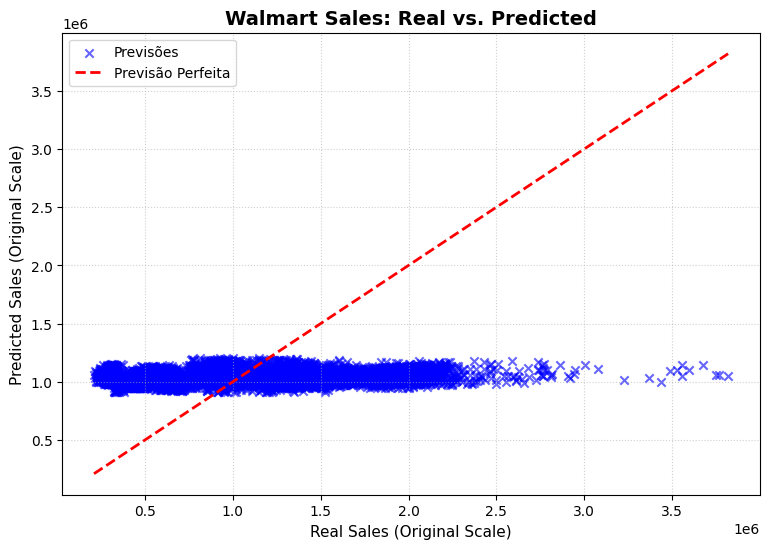

In [147]:
m = X_train.shape[0]
predicted_scaled = np.dot(X_train, w) + b


predicted_real = (predicted_scaled * desvio_sales) + media_sales
Y_train_real = (Y_train * desvio_sales) + media_sales  
plt.figure(figsize=(9, 6))


plt.scatter(Y_train_real, predicted_real, marker='x', c='blue', alpha=0.6, label='Previsões')


limites = [min(Y_train_real.min(), predicted_real.min()), max(Y_train_real.max(), predicted_real.max())]
plt.plot(limites, limites, color='red', linestyle='--', linewidth=2, label='Previsão Perfeita')


plt.title("Walmart Sales: Real vs. Predicted", fontsize=14, fontweight='bold')
plt.xlabel("Real Sales (Original Scale)", fontsize=11)
plt.ylabel("Predicted Sales (Original Scale)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()


plt.show()